# 02b — Signal density with a known reference (NCE)

An isolated experiment before continuing notebook 02. Train **one signal candidate** with balanced binary cross entropy and logit
$$
\ell_\psi(x)=f_\psi(x)-\log m(x).
$$
The saved reference flow is frozen. Training noise is now $m=0.8q_\phi+0.2g_{\mathrm{broad}}$, where the broad Gaussian has twice the fitted envelope widths. The NN models the signal log density rather than learning both sides of the ratio. With equal class priors the optimal logit is $\log p_S-\log m$.

We use an integrable parameterization: $f_\psi=\log g + 30\tanh(h_\psi/30)+c$, where $g$ is a diagonal Gaussian fitted only to optimization signal events. The four-layer, 1024-wide SiLU network learns a bounded correction; $c$ is a learned scalar normalization offset. This is also an architectural change from the baseline classifier, so a successful result would not isolate the effect of the known-reference term alone. Finite integrability does **not** guarantee accurate importance-sampling normalization or correct far tails.

Reuse the current TAG, saved signal sample and reference flow. No background model is required. Nothing is installed into the main hybrid model. Candidate files go under `hybrid/signal_nce/known_mixture_gaussian_v2/`. A GPU and sufficient host RAM for the 20M-event pool are recommended. The full training is substantial; interrupted training resumes from the last completed epoch.

This new experiment addresses the artificial tail mass found in v1. Both signal and noise events use **log m** during training. Downstream signal/reference diagnostics still use **f - log q**, so their meaning and baseline comparisons are unchanged. The old candidate remains in its original directory.


In [1]:
# Keep the existing run: this experiment has its own output directory.
import os
import sys
import subprocess
from pathlib import Path

TAG = "sb10_exppoly_10m_slowlr_v3_20261001"  # Fresh run: 10M nominal-ratio events per class and gradual LR decay.
RUN_NAME = TAG
USE_DRIVE = True
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO = Path("/content/nsbi_calibration_toolkit")
    BRANCH = "ml4hep_school_tutorial"
    if not (REPO / ".git").exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--filter=blob:none", "--sparse",
            "--branch", BRANCH,
            "https://github.com/rafaellopesdesa/nsbi-lhc-toolkit.git", str(REPO),
        ], check=True, env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"})
        subprocess.run([
            "git", "-C", str(REPO), "sparse-checkout", "set", "src",
            "workshops/ml4hep_tifr_colab/calibration",
        ], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only", "origin", BRANCH], check=True)
    SOURCE = REPO / "workshops/ml4hep_tifr_colab/calibration"
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q", "-r",
        str(SOURCE / "requirements.txt"),
    ], check=True)
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")
        RUN_BASE = Path("/content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs")
    else:
        RUN_BASE = Path("/content/calibration_runs")
else:
    # Open the notebook with calibration/ as its working directory.
    SOURCE = Path.cwd().resolve()
    REPO = SOURCE.parents[2]
    RUN_BASE = SOURCE / "runs"

sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(SOURCE))
os.chdir(SOURCE)
RUN = Path(os.environ.get("CALIBRATION_RUN", RUN_BASE / RUN_NAME)).resolve()
RUN.mkdir(parents=True, exist_ok=True)
print("Source:", SOURCE)
print("TAG:", TAG)
print("Run:", RUN)
if "CALIBRATION_RUN" in os.environ:
    print("CALIBRATION_RUN overrides the tagged path; verify that it points to the intended run.")
print("Use a fresh kernel when switching between the old exercises and calibration.")

Mounted at /content/drive
Source: /content/nsbi_calibration_toolkit/workshops/ml4hep_tifr_colab/calibration
TAG: sb10_exppoly_10m_slowlr_v3_20261001
Run: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001
Use a fresh kernel when switching between the old exercises and calibration.


In [2]:

import gc
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.special import logsumexp
from IPython.display import display
from flow_reference import ReferenceFlow
from sampling import read_sample
from signal_nce import SignalNCE, train_signal, log_density, signal_envelope
from signal_mixture_noise import mixture_log_prob, sample_mixture, broad_monitor

EXPERIMENT = 'known_mixture_gaussian_v2'
NOISE = dict(broad_fraction=0.2, width_scale=2.0)
MONITOR = dict(n=100_000, seed=7_202_812, width_scale=2.0, every=5)
TRAIN = True  # False: load the saved best candidate and rerun diagnostics only.
N_PER_CLASS = 10_000_000  # Pool size, before the 60/15/25 split.
N_DIAGNOSTIC = 1_000_000
N_NORMALIZATION = 1_000_000
DIAGNOSTIC_SEED = 7_212_610  # Fresh final banks, independent of training and monitor.
SETTINGS = dict(seed=7202610, epochs=150, batch_size=4096,
                width=1024, layers=4, bound=30., learning_rate=1e-3)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
ROOT = RUN / 'hybrid'
OUT = ROOT / 'signal_nce' / EXPERIMENT
OUT.mkdir(parents=True, exist_ok=True)
REFERENCE = ROOT / 'reference.pt'
SAMPLE = RUN / 'samples' / 'signal.parquet'
for path in [REFERENCE, SAMPLE, RUN / 'config.json', ROOT / 'ratios/signal/ensemble.json']:
    if not path.is_file():
        raise FileNotFoundError(f'Required existing artifact missing: {path}')

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(2**20), b''):
            h.update(block)
    return h.hexdigest()

PROVENANCE = dict(reference_sha256=sha256_file(REFERENCE),
                  config_sha256=sha256_file(RUN / 'config.json'),
                  trainer_sha256=sha256_file(SOURCE / 'signal_nce.py'),
                  mixture_helper_sha256=sha256_file(SOURCE / 'signal_mixture_noise.py'),
                  monitor_helper_sha256=sha256_file(SOURCE / 'signal_tail_diagnostics.py'),
                  noise=NOISE, monitor=MONITOR,
                  sample_path=str(SAMPLE), sample_bytes=SAMPLE.stat().st_size,
                  sample_mtime_ns=SAMPLE.stat().st_mtime_ns,
                  noise_seed=SETTINGS['seed'] + 101)
flow = ReferenceFlow.load(REFERENCE, DEVICE)
flow.flow.eval()
for parameter in flow.flow.parameters():
    parameter.requires_grad_(False)
print('Device:', DEVICE, '\nCandidate:', OUT)
print('The saved baseline and reference will not be overwritten.')

Device: cuda 
Candidate: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/signal_nce/known_mixture_gaussian_v2
The saved baseline and reference will not be overwritten.


## Train or resume

10M signal events from the existing `ratio_train` partition and 10M negative events: 8M frozen-flow draws and 2M draws from the twice-width Gaussian. Component rows are shuffled before splitting. The mixture and candidate envelopes use the same optimization-only signal fit. Each class has 6M optimization, 1.5M validation and 2.5M reserved events. The Gaussian envelope uses only optimization events. Every batch is balanced, so no class-prior correction is required. NAdam starts at $10^{-3}$; StepLR halves it every ten epochs through 150 epochs (about $6.1\times10^{-8}$ in epochs 141–150). Checkpoint selection uses validation BCE only.

The cached arrays include mixture log densities on both classes, avoiding repeated flow evaluation. Cache metadata must match exactly; use a new experiment name when changing settings or inputs. Rerunning with completed checkpoints skips optimization. The reserved pool is not used for model selection; the comparisons below use independently generated events.

A fixed independent 100k-event broad-Gaussian bank monitors the unnormalized signal integral, ESS and largest weight share at epoch 1 and every five epochs. It never enters the training gradients or checkpoint ranking; the best checkpoint still uses validation BCE alone. This monitor is a warning, not certification. Fresh, larger final integration banks remain the acceptance check. Training/validation BCE is now against **m**, and should not be compared numerically with the old q-based training history.


Broad monitor epoch 1: integral=1.12015, ESS=3202.8, max share=0.00189
Epoch 001: LR=0.001, train=0.613943, val=0.612400
Epoch 002: LR=0.001, train=0.609278, val=0.609228
Epoch 003: LR=0.001, train=0.608901, val=0.609502
Epoch 004: LR=0.001, train=0.608733, val=0.608921
Broad monitor epoch 5: integral=1.02145, ESS=3479.1, max share=0.00153
Epoch 005: LR=0.001, train=0.608610, val=0.608534
Epoch 006: LR=0.001, train=0.608500, val=0.608636
Epoch 007: LR=0.001, train=0.608422, val=0.608587
Epoch 008: LR=0.001, train=0.608382, val=0.608749
Epoch 009: LR=0.001, train=0.608320, val=0.608589
Broad monitor epoch 10: integral=0.987567, ESS=3399.6, max share=0.00158
Epoch 010: LR=0.001, train=0.608287, val=0.608439
Epoch 011: LR=0.0005, train=0.608047, val=0.608351
Epoch 012: LR=0.0005, train=0.608038, val=0.608339
Epoch 013: LR=0.0005, train=0.608023, val=0.608316
Epoch 014: LR=0.0005, train=0.608018, val=0.608368
Broad monitor epoch 15: integral=1.01683, ESS=3378.6, max share=0.00158
Epoch 015

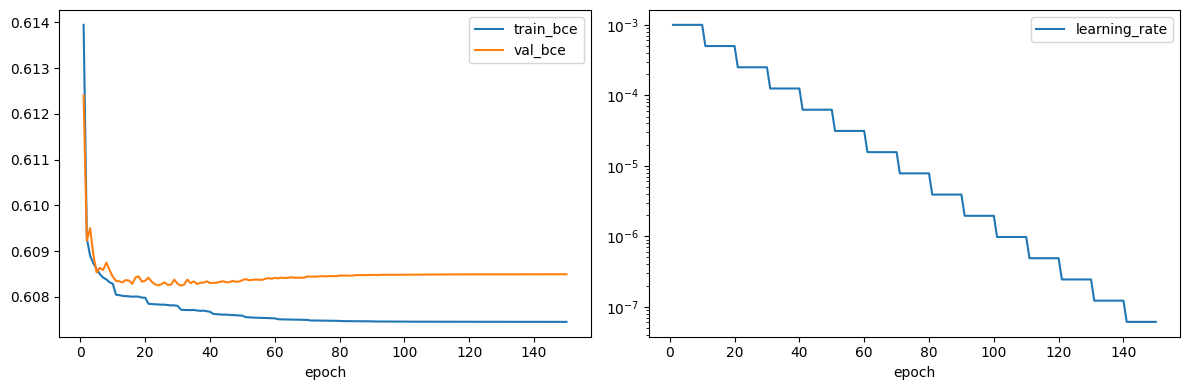

,epoch,broad_mean,broad_mc_se,broad_ess,broad_largest_weight_fraction
0,1,1.120147,0.019473,3202.816414,0.001894
4,5,1.021452,0.017014,3479.073924,0.001534
9,10,0.987567,0.016647,3399.597089,0.001575
14,15,1.016834,0.017196,3378.561189,0.001583
19,20,1.015496,0.017464,3270.770923,0.001611
24,25,0.997905,0.016889,3373.389223,0.001591
29,30,1.014826,0.017081,3409.660870,0.001571
34,35,1.027663,0.017359,3386.124138,0.001590
39,40,1.022525,0.017441,3323.148304,0.001611
44,45,1.015912,0.017303,3332.236730,0.001604


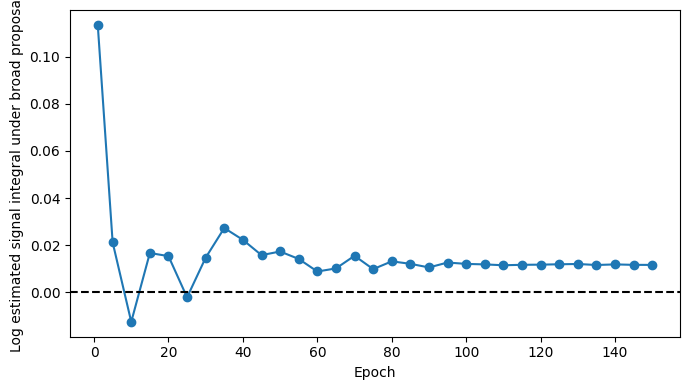

In [3]:
if TRAIN:
    cache = OUT / 'training_cache'
    cache.mkdir(exist_ok=True)
    cache_identity = dict(provenance=PROVENANCE, n_per_class=N_PER_CLASS)
    marker = cache / 'complete.json'
    paths = {name: cache / f'{name}.npy' for name in ['signal', 'noise', 'logm_signal', 'logm_noise']}
    if marker.exists():
        if json.loads(marker.read_text()) != cache_identity:
            raise ValueError('Cache provenance changed. Choose a new EXPERIMENT.')
        if not all(p.is_file() for p in paths.values()) or not (cache / 'envelope.json').is_file():
            raise FileNotFoundError('Incomplete cache: remove complete.json and rerun this cell.')
    else:
        x = read_sample(RUN, 'signal', partition='ratio_train', n=N_PER_CLASS)
        np.save(paths['signal'], x)
        envelope_mean, envelope_std = signal_envelope(x, SETTINGS['seed'])
        np.save(paths['logm_signal'], mixture_log_prob(x, flow, envelope_mean, envelope_std, **NOISE))
        (cache / 'envelope.json').write_text(json.dumps(dict(mean=envelope_mean.tolist(), std=envelope_std.tolist()), indent=2))
        del x
        gc.collect()
        x = sample_mixture(N_PER_CLASS, flow, envelope_mean, envelope_std, PROVENANCE['noise_seed'], **NOISE)
        np.save(paths['noise'], x)
        np.save(paths['logm_noise'], mixture_log_prob(x, flow, envelope_mean, envelope_std, **NOISE))
        del x
        gc.collect()
        marker.write_text(json.dumps(cache_identity, indent=2))
    arrays = {k: np.load(p, mmap_mode='r') for k, p in paths.items()}
    envelope = json.loads((cache / 'envelope.json').read_text())
    monitor = broad_monitor(np.array(envelope['mean']), np.array(envelope['std']), **MONITOR)
    candidate, history = train_signal(arrays['signal'], arrays['noise'],
                                      arrays['logm_signal'], arrays['logm_noise'],
                                      OUT, SETTINGS, PROVENANCE, device=DEVICE, monitor=monitor)
    del arrays
    gc.collect()
else:
    checkpoint = torch.load(OUT / 'best.pt', map_location=DEVICE, weights_only=False)
    identity = checkpoint['identity']
    if (identity['provenance'] != PROVENANCE or identity['settings'] != SETTINGS
            or identity['n_per_class'] != N_PER_CLASS):
        raise ValueError('Saved candidate does not match the requested experiment.')
    candidate = SignalNCE(**checkpoint['architecture']).to(DEVICE)
    candidate.load_state_dict(checkpoint['model'])
    candidate.eval()
    history = json.loads((OUT / 'history.json').read_text())
    print('Loaded best epoch:', checkpoint['epoch'])

history_frame = pd.DataFrame(history)
history_frame.to_csv(OUT / 'history.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_frame.plot(x='epoch', y=['train_bce', 'val_bce'], ax=axes[0])
history_frame.plot(x='epoch', y='learning_rate', logy=True, ax=axes[1])
fig.tight_layout()
fig.savefig(OUT / 'training.png', dpi=150)
plt.show()

monitor_rows = history_frame.dropna(subset=['broad_log_mean']) if 'broad_log_mean' in history_frame else pd.DataFrame()
if not monitor_rows.empty:
    display(monitor_rows[['epoch', 'broad_mean', 'broad_mc_se', 'broad_ess', 'broad_largest_weight_fraction']])
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(monitor_rows.epoch, monitor_rows.broad_log_mean, marker='o')
    ax.axhline(0, color='k', linestyle='--')
    ax.set(xlabel='Epoch', ylabel='Log estimated signal integral under broad proposal')
    fig.tight_layout()
    fig.savefig(OUT / 'broad_training_monitor.png', dpi=150)
    plt.show()


## Fresh comparison: candidate, baseline ensemble and exact oracle

These events are independent of optimization and validation. This common-reference comparison uses $f-\log q$ for BCE and classifier calibration; the training logit is $f-\log m$. Compare paired BCE differences, exact log-ratio errors, and the populated tail bins together. A visually better reliability curve alone does not establish a better density. Approximate pointwise intervals can be unreliable in sparse bins; inspect their counts.

Reports are generated separately: the candidate is **never averaged with the baseline**. The exact simulator density appears for the first time here. It cannot affect checkpoint selection. Once these diagnostics guide development, use a new diagnostic seed for final validation.

,model,members,n_num,n_den,bce,bce_se,bce_excess_exact,bce_excess_exact_se,bce_excess_exact_low95,bce_excess_exact_high95,...,mean_log_error_num,mean_log_error_se_num,rms_log_error_num,tail_score_gt_075_num,tail_score_gt_090_num,mean_log_error_den,mean_log_error_se_den,rms_log_error_den,tail_score_gt_075_den,tail_score_gt_090_den
0,Member 1,1,1000000,1000000,0.631130,0.000216,0.001377,0.000037,0.001305,0.001449,...,-0.005442,0.000295,0.294966,0.001141,0.000805,-0.000562,0.000112,0.111909,0.000199,0.000029
1,Member 2,1,1000000,1000000,0.631160,0.000215,0.001406,0.000037,0.001334,0.001478,...,0.000086,0.000297,0.297416,0.001094,0.000709,0.011955,0.000112,0.112369,0.000176,0.000027
2,Member 3,1,1000000,1000000,0.631068,0.000217,0.001314,0.000036,0.001244,0.001384,...,0.013315,0.000304,0.304192,0.001000,0.000679,0.018115,0.000109,0.110695,0.000113,0.000019
3,Member 4,1,1000000,1000000,0.631117,0.000215,0.001363,0.000036,0.001292,0.001434,...,0.005995,0.000178,0.177888,0.000934,0.000670,0.018144,0.000109,0.110815,0.000108,0.000015
4,Ensemble,4,1000000,1000000,0.630949,0.000215,0.001195,0.000034,0.001128,0.001262,...,0.005901,0.000354,0.353598,0.001079,0.000768,0.012866,0.000103,0.103794,0.000135,0.000024
5,Exact ratio,0,1000000,1000000,0.629754,0.000217,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.001607,0.000913,0.000000,0.000000,0.000000,0.000192,0.000009


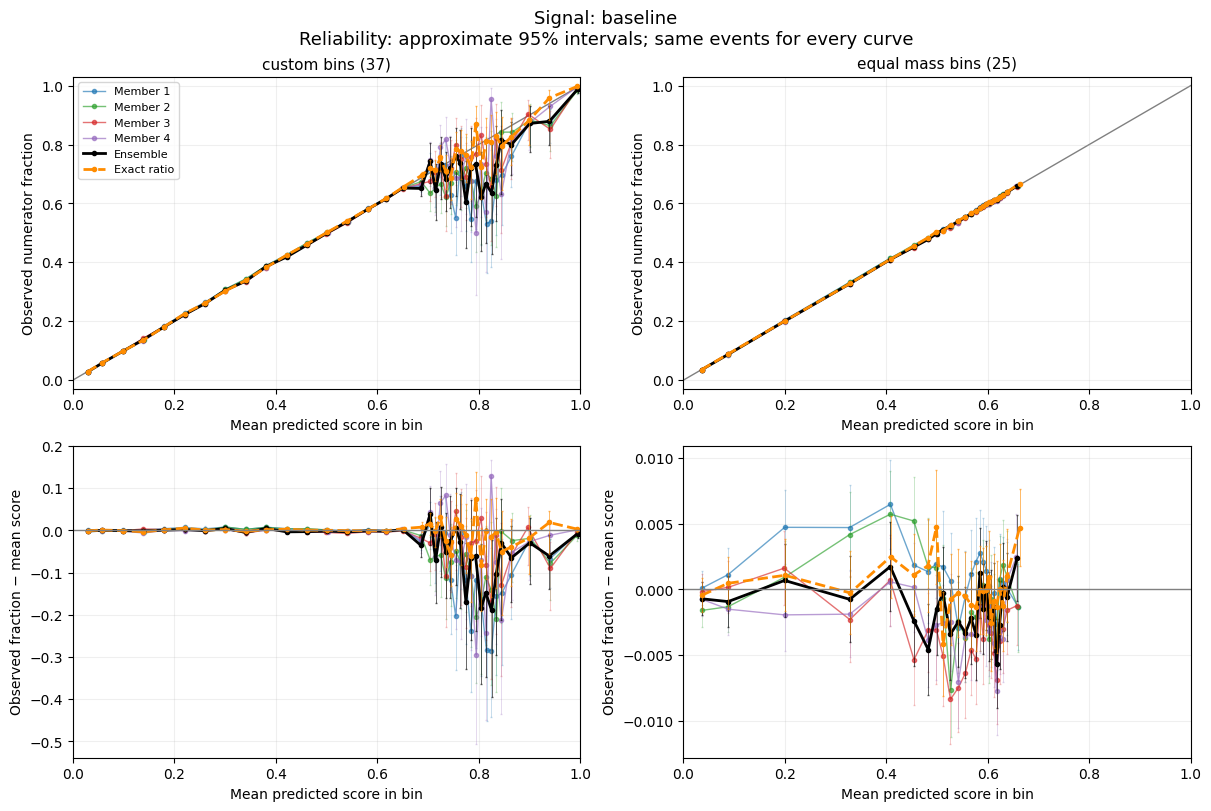

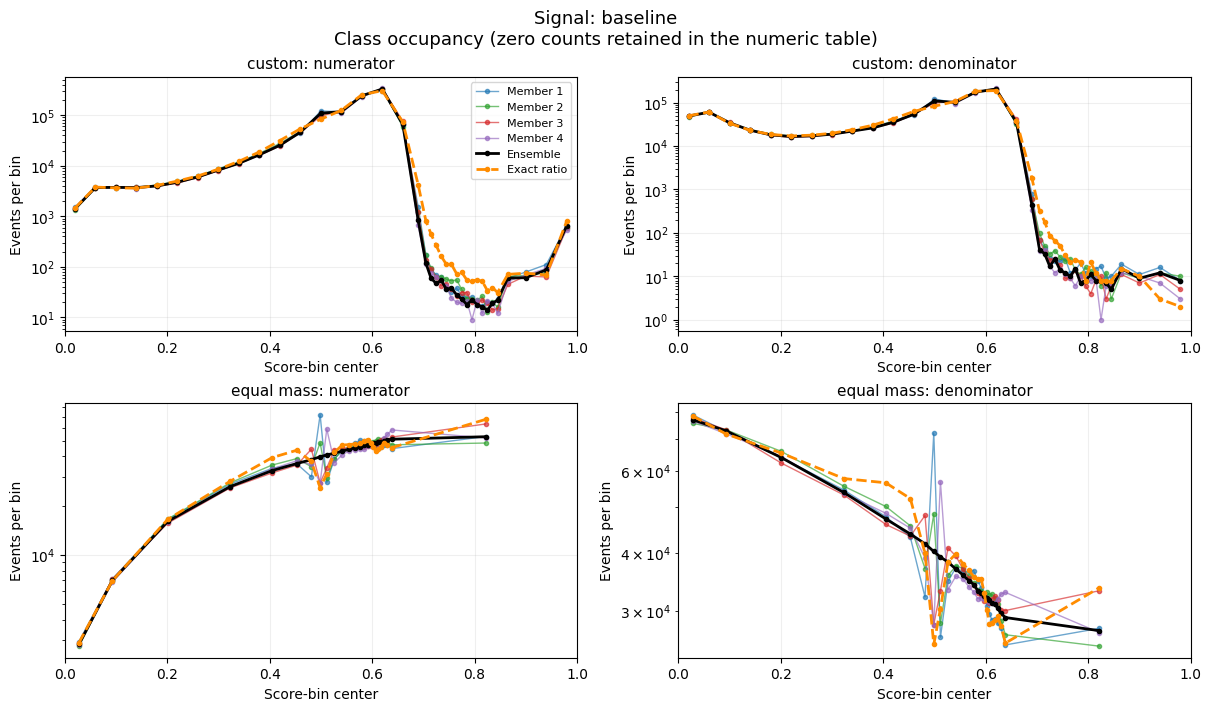

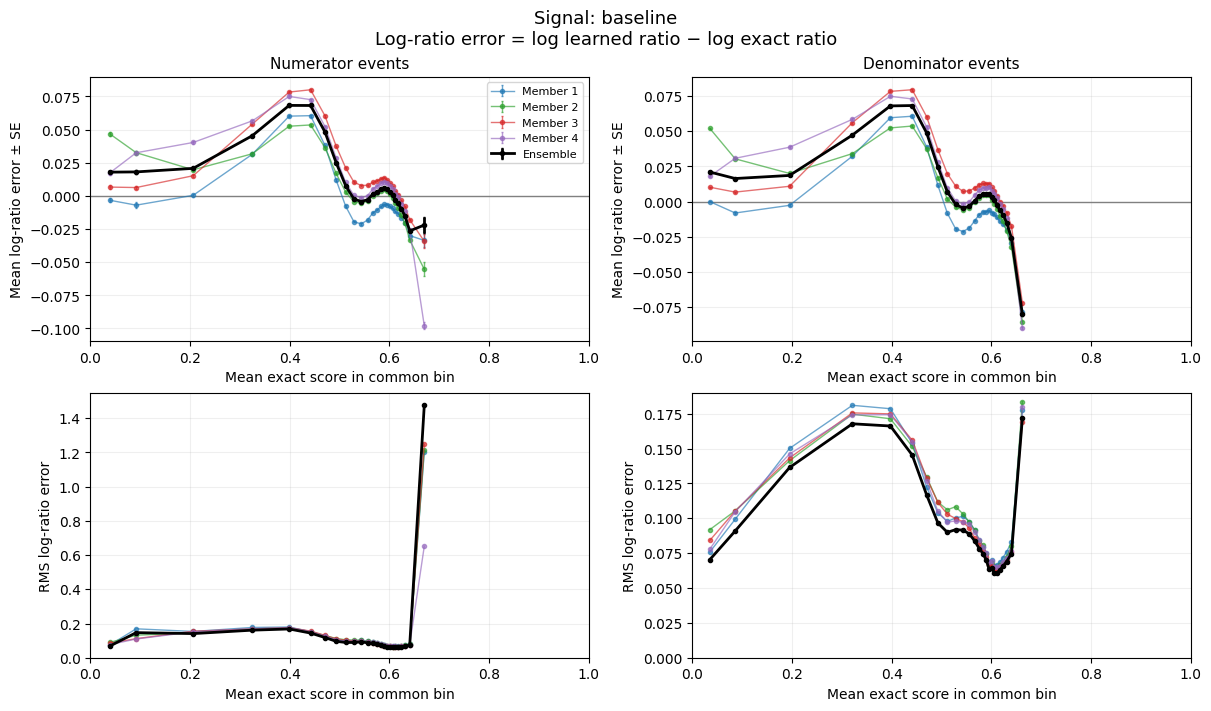

,model,members,n_num,n_den,bce,bce_se,bce_excess_exact,bce_excess_exact_se,bce_excess_exact_low95,bce_excess_exact_high95,...,mean_log_error_num,mean_log_error_se_num,rms_log_error_num,tail_score_gt_075_num,tail_score_gt_090_num,mean_log_error_den,mean_log_error_se_den,rms_log_error_den,tail_score_gt_075_den,tail_score_gt_090_den
0,Member 1,1,1000000,1000000,0.629873,0.000216,0.000119,0.000011,0.000099,0.00014,...,0.001279,0.000032,0.03208,0.001693,0.000926,0.003991,0.000032,0.031986,0.000218,0.000012
1,Ensemble,1,1000000,1000000,0.629873,0.000216,0.000119,0.000011,0.000099,0.00014,...,0.001279,0.000032,0.03208,0.001693,0.000926,0.003991,0.000032,0.031986,0.000218,0.000012
2,Exact ratio,0,1000000,1000000,0.629754,0.000217,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.00000,0.001607,0.000913,0.000000,0.000000,0.000000,0.000192,0.000009


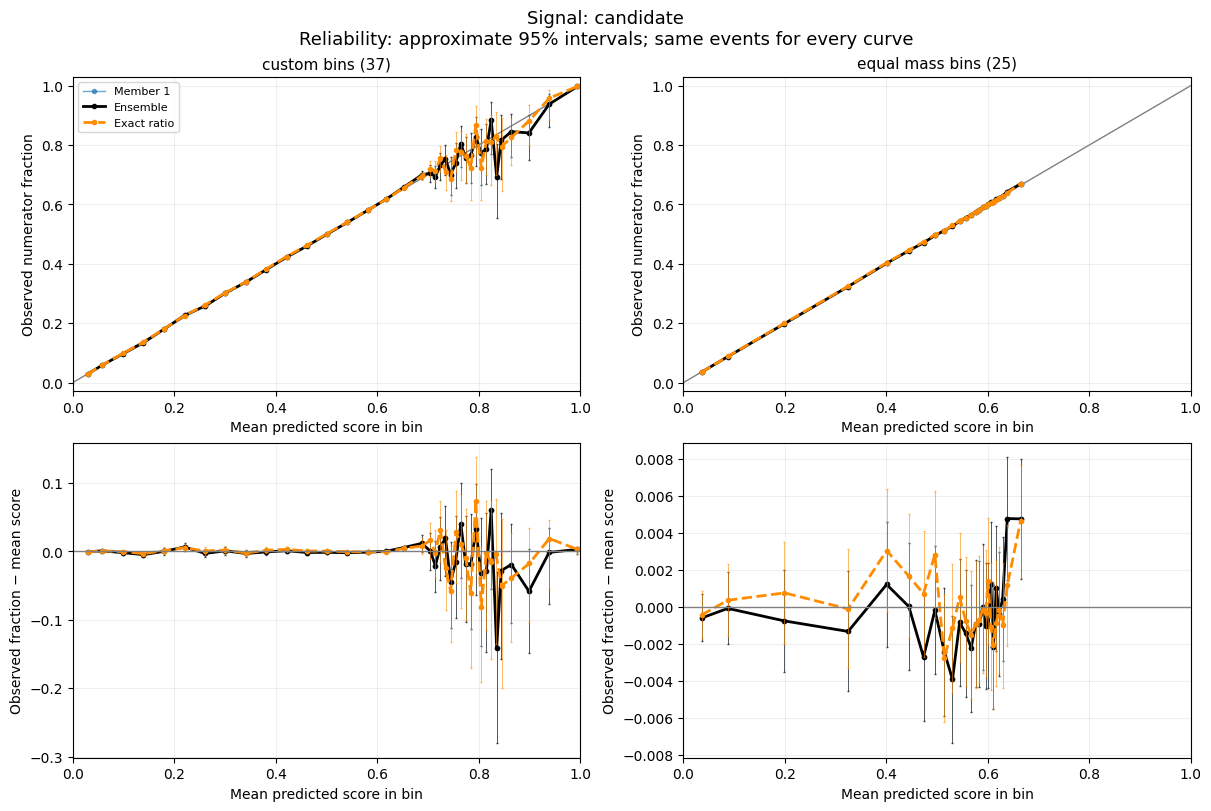

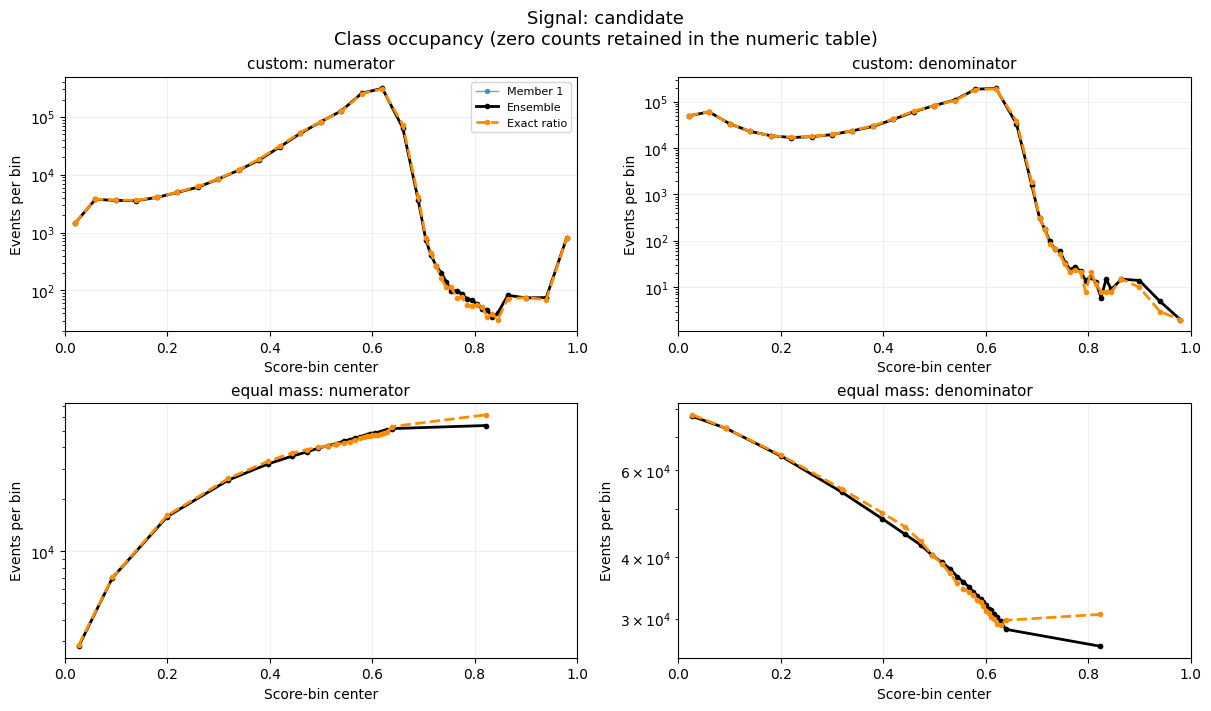

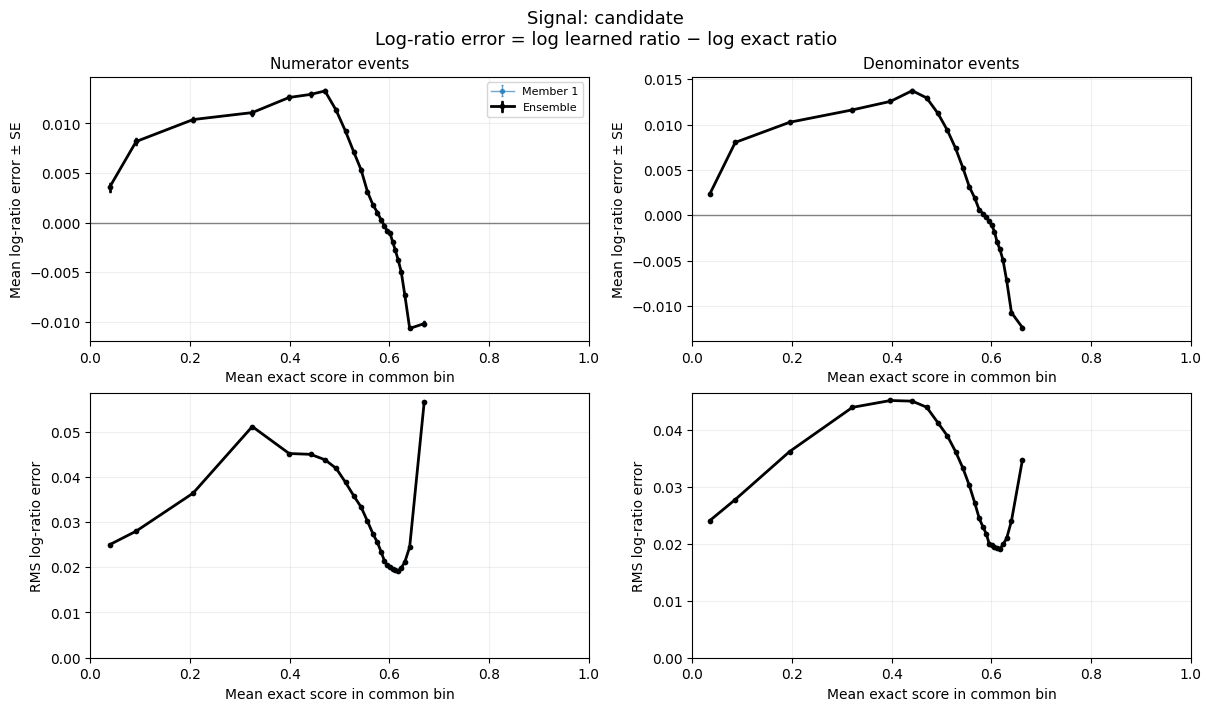

,model,members,n_num,n_den,bce,bce_se,bce_excess_exact,bce_excess_exact_se,bce_excess_exact_low95,bce_excess_exact_high95,...,mean_log_error_num,mean_log_error_se_num,rms_log_error_num,tail_score_gt_075_num,tail_score_gt_090_num,mean_log_error_den,mean_log_error_se_den,rms_log_error_den,tail_score_gt_075_den,tail_score_gt_090_den
0,Member 1,1,1000000,1000000,0.629889,0.000217,0.000135,0.000011,0.000113,0.000157,...,-0.003156,0.000034,0.034273,0.001559,0.000919,-0.001674,0.000035,0.034624,0.000197,0.000011
1,Ensemble,1,1000000,1000000,0.629889,0.000217,0.000135,0.000011,0.000113,0.000157,...,-0.003156,0.000034,0.034273,0.001559,0.000919,-0.001674,0.000035,0.034624,0.000197,0.000011
2,Exact ratio,0,1000000,1000000,0.629754,0.000217,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.001607,0.000913,0.000000,0.000000,0.000000,0.000192,0.000009


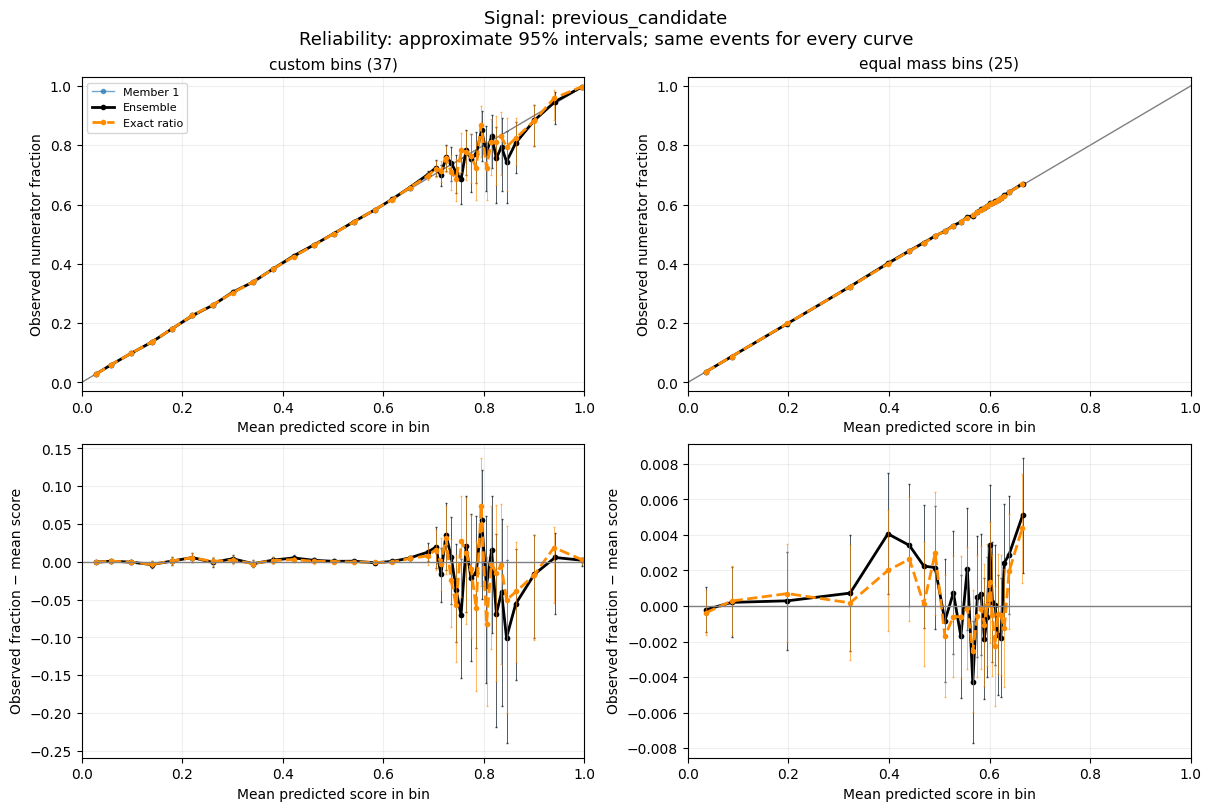

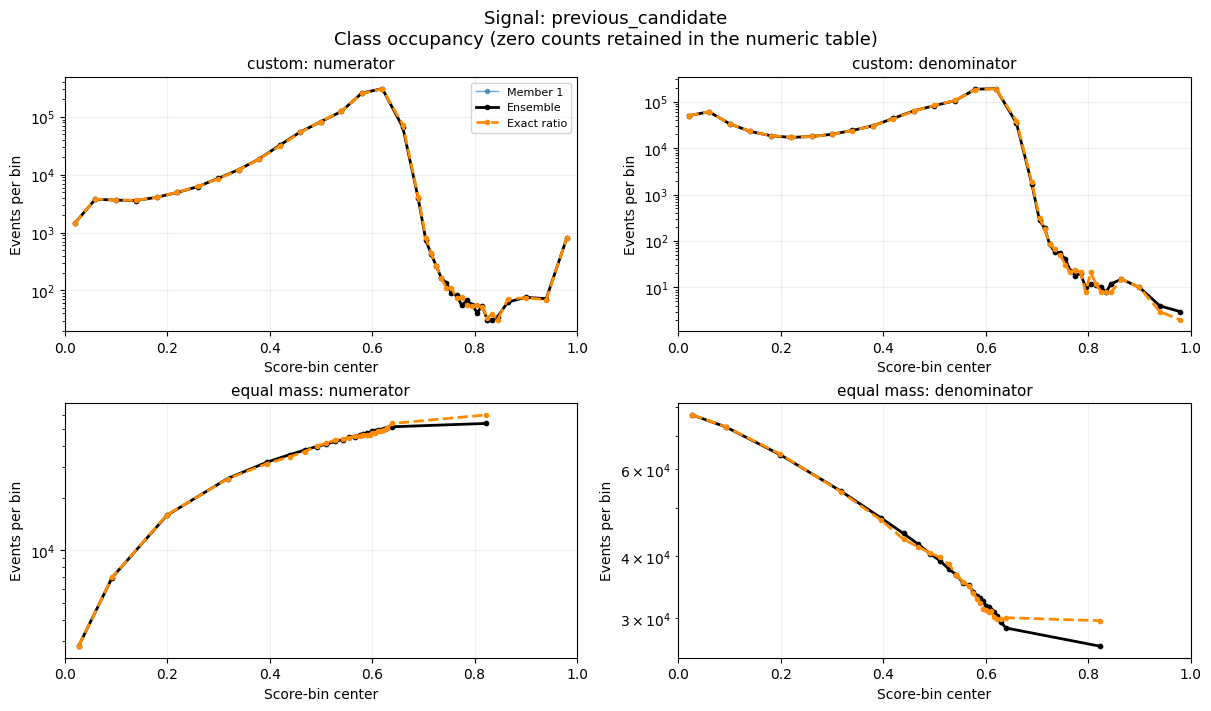

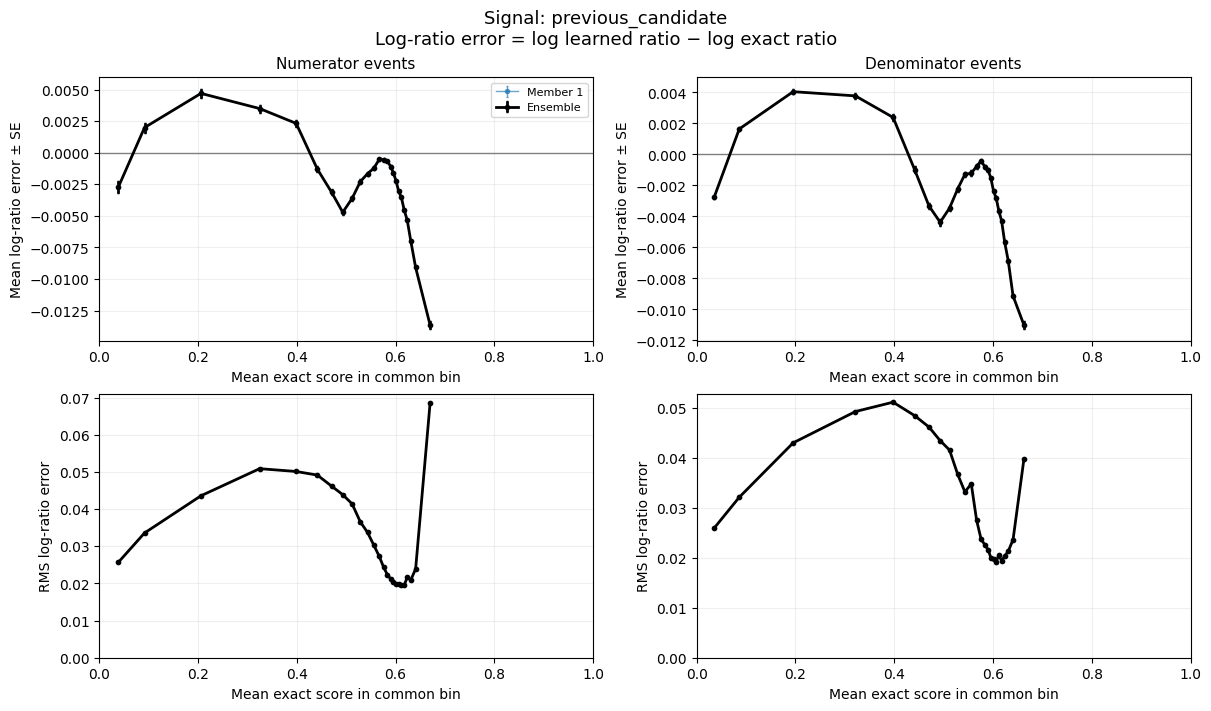

,model,members,n_num,n_den,bce,bce_se,bce_excess_exact,bce_excess_exact_se,bce_excess_exact_low95,bce_excess_exact_high95,...,mean_log_error_num,mean_log_error_se_num,rms_log_error_num,tail_score_gt_075_num,tail_score_gt_090_num,mean_log_error_den,mean_log_error_se_den,rms_log_error_den,tail_score_gt_075_den,tail_score_gt_090_den
0,baseline,4,1000000,1000000,0.630949,0.000215,0.001195,0.000034,0.001128,0.001262,...,0.005901,0.000354,0.353598,0.001079,0.000768,0.012866,0.000103,0.103794,0.000135,0.000024
1,candidate,1,1000000,1000000,0.629873,0.000216,0.000119,0.000011,0.000099,0.000140,...,0.001279,0.000032,0.032080,0.001693,0.000926,0.003991,0.000032,0.031986,0.000218,0.000012
2,previous_candidate,1,1000000,1000000,0.629889,0.000217,0.000135,0.000011,0.000113,0.000157,...,-0.003156,0.000034,0.034273,0.001559,0.000919,-0.001674,0.000035,0.034624,0.000197,0.000011


Negative favors candidate; this interval excludes training uncertainty: {'candidate_minus_baseline_bce': -0.001075431776269385, 'se': 3.5225339699466075e-05, 'low95': -0.0011444734420803385, 'high95': -0.0010063901104584317}


In [4]:
from sampling import sample_process, process_log_density
from utils import RatioEnsemble
from ratio_diagnostics import diagnostic_report

EVAL = OUT / f'diagnostics_seed_{DIAGNOSTIC_SEED}'
EVAL.mkdir(exist_ok=True)
baseline = RatioEnsemble.load(ROOT / 'ratios/signal', device=DEVICE)
x_num = sample_process('signal', N_DIAGNOSTIC, np.random.default_rng(DIAGNOSTIC_SEED))
x_den = flow.sample(N_DIAGNOSTIC, DIAGNOSTIC_SEED + 1, batch_size=8192)
q_num = flow.log_prob(x_num, batch_size=8192).astype(np.float64)
q_den = flow.log_prob(x_den, batch_size=8192).astype(np.float64)
exact_num = process_log_density(x_num, 'signal') - q_num
exact_den = process_log_density(x_den, 'signal') - q_den
candidate_num = log_density(candidate, x_num) - q_num
candidate_den = log_density(candidate, x_den) - q_den
member_num = baseline.member_log_ratios(x_num)
member_den = baseline.member_log_ratios(x_den)
baseline_num = logsumexp(member_num, axis=0) - np.log(len(member_num))
baseline_den = logsumexp(member_den, axis=0) - np.log(len(member_den))
score_edges = np.unique(np.round(np.r_[np.linspace(0, 1, 26), np.arange(.70, .851, .01)], 8))
summaries = []
models_to_report = [('baseline', member_num, member_den),
                    ('candidate', candidate_num[None, :], candidate_den[None, :])]
previous_path = ROOT / 'signal_nce/known_q_gaussian_v1/best.pt'
if previous_path.is_file():
    previous_state = torch.load(previous_path, map_location=DEVICE, weights_only=False)
    if previous_state['identity']['provenance']['reference_sha256'] != PROVENANCE['reference_sha256']:
        raise ValueError('Previous candidate used a different reference flow.')
    previous_candidate = SignalNCE(**previous_state['architecture']).to(DEVICE)
    previous_candidate.load_state_dict(previous_state['model'])
    previous_num = log_density(previous_candidate, x_num)-q_num
    previous_den = log_density(previous_candidate, x_den)-q_den
    models_to_report.append(('previous_candidate', previous_num[None, :], previous_den[None, :]))
    del previous_candidate, previous_state
else:
    print('Previous candidate checkpoint absent; baseline comparison is still available.')
for label, ln, ld in models_to_report:
    report = diagnostic_report(ln, ld, exact_num, exact_den,
                               title=f'Signal: {label}', score_edges=score_edges)
    report['summary'].to_csv(EVAL / f'{label}_summary.csv', index=False)
    report['bins'].to_csv(EVAL / f'{label}_bins.csv', index=False)
    chosen = report['summary'].query("model == 'Ensemble'").copy()
    chosen['model'] = label
    summaries.append(chosen)
    display(report['summary'])
    for name, fig in report['figures']:
        fig.savefig(EVAL / f'{label}_{name}.png', dpi=150, bbox_inches='tight')
        display(fig)
        plt.close(fig)
comparison = pd.concat(summaries, ignore_index=True)
comparison.to_csv(EVAL / 'comparison.csv', index=False)
display(comparison)

# Same-event pairing is essential: this error bar concerns evaluation statistics only.
delta_num = np.logaddexp(0, -candidate_num) - np.logaddexp(0, -baseline_num)
delta_den = np.logaddexp(0, candidate_den) - np.logaddexp(0, baseline_den)
difference = .5 * (delta_num.mean() + delta_den.mean())
se = .5 * np.sqrt(delta_num.var(ddof=1)/N_DIAGNOSTIC + delta_den.var(ddof=1)/N_DIAGNOSTIC)
paired = dict(candidate_minus_baseline_bce=float(difference), se=float(se),
              low95=float(difference-1.96*se), high95=float(difference+1.96*se))
(EVAL / 'paired_bce.json').write_text(json.dumps(paired, indent=2))
print('Negative favors candidate; this interval excludes training uncertainty:', paired)

## Independent normalization and tail stress check

Estimate $Z=E_q[\exp(f-\log q)]$ on a **separate** reference bank, then check $E_q[r/Z]$ on the diagnostic denominator bank above. The latter was not used to estimate $Z$. Also record ESS, the largest normalized weight and the fraction of total weight carried by the largest 0.1% of events. A small Monte Carlo SE is not proof that unsampled tails are harmless.

The candidate's normalized log density is $f-\log Z$. This optional scalar correction is saved separately and is not applied retroactively to raw classifier calibration. Both candidate and baseline use the same integration bank for this comparison. No candidate is promoted automatically.

In [5]:
normalization_x = flow.sample(N_NORMALIZATION, DIAGNOSTIC_SEED + 2, batch_size=8192)
normalization_q = flow.log_prob(normalization_x, batch_size=8192).astype(np.float64)
normalization_members = baseline.member_log_ratios(normalization_x)
normalization_logits = {
    'candidate': log_density(candidate, normalization_x) - normalization_q,
    'baseline': logsumexp(normalization_members, axis=0) - np.log(len(normalization_members)),
}
check_logits = {'candidate': candidate_den, 'baseline': baseline_den}
rows = []
for name, values in normalization_logits.items():
    logz = float(logsumexp(values) - np.log(len(values)))
    scaled = np.exp(values - logz)
    relative_se = float(scaled.std(ddof=1) / np.sqrt(len(scaled)))
    check = check_logits[name] - logz
    logmean = logsumexp(check) - np.log(len(check))
    normalized_weights = np.exp(check - logsumexp(check))
    k = max(1, int(np.ceil(.001 * len(check))))
    rows.append(dict(model=name, log_Z=logz, Z_relative_mc_se=relative_se,
                     independent_mean_ratio=float(np.exp(logmean)),
                     independent_mean_ratio_se=float(np.exp(logmean) *
                         np.exp(check-logmean).std(ddof=1) / np.sqrt(len(check))),
                     independent_ess=float(1 / np.square(normalized_weights).sum()),
                     maximum_normalized_ratio=float(np.exp(check.max())),
                     top_0p1_percent_weight_fraction=float(np.partition(normalized_weights, -k)[-k:].sum())))
normalization = pd.DataFrame(rows)
display(normalization)
normalization.to_csv(EVAL / 'normalization.csv', index=False)
(EVAL / 'normalization.json').write_text(json.dumps(dict(
    reference_sha256=PROVENANCE['reference_sha256'],
    checkpoint_sha256=sha256_file(OUT / 'best.pt'),
    integration_seed=DIAGNOSTIC_SEED+2, integration_size=N_NORMALIZATION,
    diagnostic_size=N_DIAGNOSTIC, results=rows), indent=2))
print('Ready for review:', EVAL)
print('Review comparison.csv, paired_bce.json, calibration/exact-error figures and normalization.csv together.')

,model,log_Z,Z_relative_mc_se,independent_mean_ratio,independent_mean_ratio_se,independent_ess,maximum_normalized_ratio,top_0p1_percent_weight_fraction
0,candidate,0.003061,0.000933,0.997286,0.000584,744839.487131,97.639305,0.003093
1,baseline,0.008030,0.000692,1.001120,0.001855,225476.568214,1407.801100,0.005907


Ready for review: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/signal_nce/known_mixture_gaussian_v2/diagnostics_seed_7212610
Review comparison.csv, paired_bce.json, calibration/exact-error figures and normalization.csv together.


## Investigate the extreme weights — no retraining

This experiment defaults to training once, then checking fresh diagnostic banks. For later diagnostics-only reruns, set `TRAIN = False` and keep this experiment name and diagnostic seed. The v1 extreme-event check below reuses the old saved coordinates explicitly. All checks below use the saved best candidate. They do not change model files, clip ratios, or replace normalization constants. Different hardware or library versions can change the sampled events; we save the selected coordinates explicitly.

We inspect the union of the 20 largest candidate, baseline and **exact** ratios in each of the two reference banks. The decomposition
$$
\log r_{\mathrm{candidate}}-\log r_{\mathrm{exact}}=f_\psi-\log p_S
$$
removes the shared reference term. It tells us whether the candidate overpredicts the signal density at the offending event. Large exact weights also point toward reference coverage or reference numerics. Table means below use **raw** ratios: the exact ratio should have population mean one. Monte Carlo standard errors and ESS can be misleading when rare events dominate.

,bank,model,n,log_mean,mean,relative_mc_se,mc_se,ess,max_log_weight,largest_weight_fraction,top_10_weight_fraction,remaining_contribution_after_largest_to_full_bank_mean
0,diagnostic_q,candidate,1000000,0.000343,1.000343,0.000585,0.000585,744839.487131,4.584341,0.000098,0.000247,1.000245
1,diagnostic_q,baseline,1000000,0.009150,1.009192,0.001853,0.001870,225476.568214,7.257815,0.001406,0.003344,1.007773
2,diagnostic_q,exact,1000000,-0.001362,0.998639,0.000589,0.000588,742345.685061,4.601342,0.000100,0.000241,0.998539
3,normalization_q,candidate,1000000,0.003061,1.003066,0.000933,0.000936,534530.104962,6.524174,0.000679,0.001264,1.002384
4,normalization_q,baseline,1000000,0.008030,1.008063,0.000692,0.000698,676079.526619,5.855162,0.000346,0.000735,1.007714
5,normalization_q,exact,1000000,0.001017,1.001017,0.000707,0.000708,666778.288797,5.747575,0.000313,0.000856,1.000704


Largest candidate weights: diagnostic_q


,bank,event_index,x1,x2,x3,x4,x5,log_q32,log_p_exact,f_candidate32,log_g,candidate_minus_exact_logp,bounded_residual_plus_offset,gaussian_radius_squared,candidate_top_rank,candidate_log_ratio,candidate_weight_fraction,baseline_top_rank,baseline_log_ratio,baseline_weight_fraction,exact_top_rank,exact_log_ratio,exact_weight_fraction
0,diagnostic_q,129700,4.791538,4.092898,-5.917992,1.799674,3.312066,-21.968462,-17.367120,-17.384121,-23.455371,-0.017001,6.071250,32.091460,1.0,4.584341,0.000098,12.0,2.712890,0.000015,1.0,4.601342,0.000100
1,diagnostic_q,91660,7.020280,11.731787,7.185159,2.530683,7.111717,-25.300640,-21.519675,-21.685734,-26.895327,-0.166058,5.209593,38.971372,2.0,3.614906,0.000037,1.0,7.257815,0.001406,2.0,3.780965,0.000044
2,diagnostic_q,840770,-6.416829,-5.084602,4.843056,-2.589270,1.006442,-23.455545,-21.025311,-20.417776,-41.114848,0.607535,20.697072,67.410415,3.0,3.037769,0.000021,NaN,0.042427,0.000001,6.0,2.430235,0.000011
3,diagnostic_q,133478,15.728745,-0.698588,0.152640,0.546115,4.173929,-23.615063,-20.741611,-20.663818,-26.769046,0.077793,6.105228,38.718812,4.0,2.951244,0.000019,NaN,0.585643,0.000002,3.0,2.873452,0.000018
4,diagnostic_q,92156,-3.956074,-5.982079,3.892780,-0.956241,0.035172,-21.699894,-19.367434,-19.016684,-38.346670,0.350750,19.329986,61.874058,5.0,2.683210,0.000015,NaN,0.925922,0.000003,8.0,2.332460,0.000010
5,diagnostic_q,741657,8.722393,2.934311,2.341409,4.473720,-5.122743,-20.812605,-18.117649,-18.156483,-26.812271,-0.038834,8.655789,38.805261,6.0,2.656122,0.000014,NaN,2.356291,0.000010,4.0,2.694956,0.000015
6,diagnostic_q,849655,2.818906,7.616761,4.000881,8.834578,5.292004,-20.487724,-17.880884,-17.975777,-19.064203,-0.094892,1.088426,23.309125,7.0,2.511948,0.000012,NaN,1.442958,0.000004,5.0,2.606840,0.000014
7,diagnostic_q,57651,1.160817,1.711612,2.850713,10.953294,1.503949,-20.275688,-17.931902,-17.887383,-22.297748,0.044519,4.410366,29.776215,8.0,2.388306,0.000011,6.0,4.248731,0.000069,7.0,2.343786,0.000010
8,diagnostic_q,773720,-1.591360,4.944443,13.259816,6.219308,1.278684,-24.507860,-22.177123,-22.196518,-28.990235,-0.019395,6.793717,43.161189,9.0,2.311342,0.000010,NaN,0.859490,0.000002,9.0,2.330738,0.000010
9,diagnostic_q,435855,-4.612882,10.104589,4.112401,-0.634023,2.703223,-21.119200,-18.975232,-18.875067,-28.603804,0.100165,9.728737,42.388326,10.0,2.244133,0.000009,NaN,0.706125,0.000002,13.0,2.143968,0.000009


Largest candidate weights: normalization_q


,bank,event_index,x1,x2,x3,x4,x5,log_q32,log_p_exact,f_candidate32,log_g,candidate_minus_exact_logp,bounded_residual_plus_offset,gaussian_radius_squared,candidate_top_rank,candidate_log_ratio,candidate_weight_fraction,baseline_top_rank,baseline_log_ratio,baseline_weight_fraction,exact_top_rank,exact_log_ratio,exact_weight_fraction
40,normalization_q,200305,-3.023154,-1.041201,3.302236,5.983924,-5.270762,-25.731030,-19.983455,-19.206856,-37.420645,0.776599,18.213789,60.022009,1.0,6.524174,0.000679,4.0,3.479254,3.217609e-05,1.0,5.747575,0.000313
41,normalization_q,709746,0.423667,-6.309195,0.455434,4.436121,6.060613,-24.019163,-18.787747,-18.683491,-33.023745,0.104257,14.340255,51.228210,2.0,5.335672,0.000207,9.0,2.953822,1.902571e-05,2.0,5.231416,0.000187
42,normalization_q,58690,-7.955005,2.555502,2.793633,4.190468,6.271256,-23.937147,-18.843623,-18.775663,-27.916457,0.067959,9.140794,41.013633,3.0,5.161484,0.000174,2.0,5.182741,1.767454e-04,3.0,5.093525,0.000163
43,normalization_q,970018,2.124023,2.824946,-5.936909,2.432161,2.353036,-21.422621,-17.055685,-17.022524,-24.584355,0.033161,7.561831,34.349429,4.0,4.400097,0.000081,NaN,2.092512,8.040426e-06,4.0,4.366936,0.000079
44,normalization_q,173869,13.999397,6.343625,8.029459,0.187010,6.234404,-24.948147,-21.506615,-21.306652,-22.807893,0.199963,1.501241,30.796504,5.0,3.641495,0.000038,NaN,0.367910,1.433157e-06,5.0,3.441532,0.000031
45,normalization_q,423035,2.345208,-6.085615,5.066367,-0.959414,0.979156,-20.390240,-17.051288,-16.933529,-29.702289,0.117759,12.768760,44.585296,6.0,3.456711,0.000032,NaN,2.139414,8.426515e-06,6.0,3.338952,0.000028
46,normalization_q,33399,0.540323,4.704357,12.620969,-1.492341,3.369665,-22.022259,-19.333884,-19.234169,-22.829971,0.099715,3.595802,30.840661,7.0,2.788090,0.000016,NaN,0.453706,1.561544e-06,7.0,2.688374,0.000015
47,normalization_q,279270,8.013923,9.477465,7.303486,2.266941,7.755664,-22.346437,-19.783407,-19.780878,-21.554594,0.002529,1.773716,28.289907,8.0,2.565559,0.000013,NaN,1.244092,3.442031e-06,10.0,2.563030,0.000013
48,normalization_q,995872,10.283553,10.618519,-2.496814,3.555496,1.169671,-23.833010,-21.544445,-21.290331,-30.763563,0.254115,9.473232,46.707844,9.0,2.542679,0.000013,NaN,-0.403815,6.624267e-07,11.0,2.288564,0.000010
49,normalization_q,832182,2.451010,0.628589,-1.654332,-0.647455,11.531595,-22.170679,-19.564355,-19.734282,-28.642154,-0.169926,8.907873,42.465027,10.0,2.436398,0.000011,NaN,2.100384,8.103965e-06,9.0,2.606324,0.000014


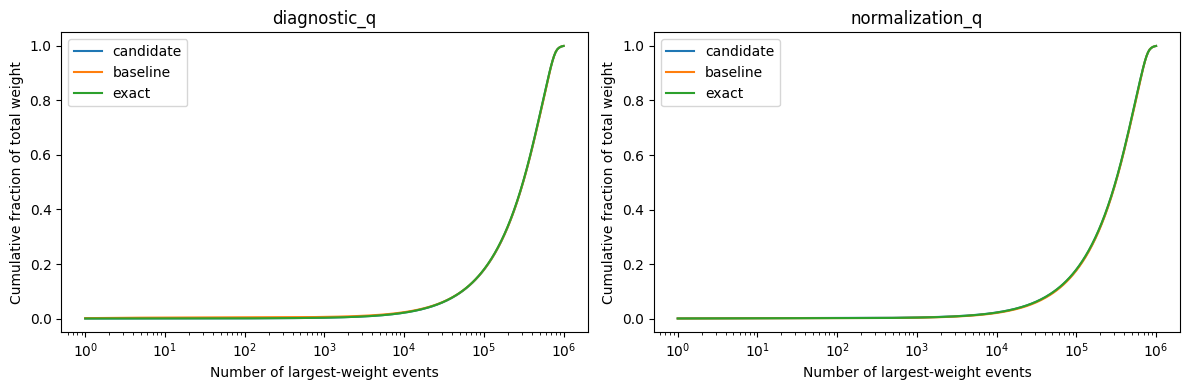

527

In [6]:
from signal_tail_diagnostics import (weight_summary, gaussian_log_density,
                                     tail_table, precision_probe)
import importlib.metadata

TOP_K = 20
TAIL = EVAL / 'tail_investigation'
TAIL.mkdir(exist_ok=True)
g_mean = candidate.mean.detach().cpu().numpy().astype(np.float64)
g_std = candidate.std.detach().cpu().numpy().astype(np.float64)
exact_normalization = process_log_density(normalization_x, 'signal') - normalization_q
banks = {
    'diagnostic_q': dict(x=x_den, q=q_den, candidate=candidate_den,
                         baseline=baseline_den, exact=exact_den),
    'normalization_q': dict(x=normalization_x, q=normalization_q,
                            candidate=normalization_logits['candidate'],
                            baseline=normalization_logits['baseline'], exact=exact_normalization),
}
tables, summaries = [], []
for bank_name, bank in banks.items():
    table = tail_table(bank_name, bank['x'], bank['q'], bank['candidate'],
                       bank['baseline'], bank['exact'], g_mean, g_std, TOP_K)
    tables.append(table)
    np.savez_compressed(TAIL / f'{bank_name}_extreme_events.npz',
                        event_index=table.event_index.to_numpy(),
                        x=bank['x'][table.event_index.to_numpy()])
    for name in ['candidate', 'baseline', 'exact']:
        v = bank[name]
        summary = weight_summary(v)
        # Influence diagnostic only: removing events is NOT a normalization fix.
        biggest = int(np.argmax(v))
        remainder = np.delete(v, biggest)
        summary['remaining_contribution_after_largest_to_full_bank_mean'] = float(
            np.exp(logsumexp(remainder)-np.log(len(v))))
        summaries.append(dict(bank=bank_name, model=name, **summary))
tails = pd.concat(tables, ignore_index=True)
tails.to_csv(TAIL / 'extreme_events.csv', index=False)
weights = pd.DataFrame(summaries)
weights.to_csv(TAIL / 'reference_bank_weights.csv', index=False)
with pd.option_context('display.max_columns', None, 'display.width', 240):
    display(weights)
    for bank_name in banks:
        print('Largest candidate weights:', bank_name)
        display(tails[tails.bank.eq(bank_name)].head(10))
# Plots explicitly retain the single-event contribution.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (bank_name, bank) in zip(axes, banks.items()):
    for name in ['candidate', 'baseline', 'exact']:
        v = bank[name]
        fraction = np.exp(np.sort(v)[::-1]-logsumexp(v))
        counts = np.unique(np.geomspace(1, len(v), 300).astype(int))
        ax.plot(counts, np.cumsum(fraction)[counts-1], label=name)
    ax.set(xscale='log', xlabel='Number of largest-weight events',
           ylabel='Cumulative fraction of total weight', title=bank_name)
    ax.legend()
fig.tight_layout()
fig.savefig(TAIL / 'weight_concentration.png', dpi=150)
plt.show()
manifest = dict(diagnostic_seed=DIAGNOSTIC_SEED, normalization_seed=DIAGNOSTIC_SEED+2,
                n_diagnostic=N_DIAGNOSTIC, n_normalization=N_NORMALIZATION,
                sampling_batch_size=8192, top_k=TOP_K, device=DEVICE,
                torch=str(torch.__version__), numpy=np.__version__,
                nflows=importlib.metadata.version('nflows'),
                candidate_sha256=sha256_file(OUT / 'best.pt'),
                reference_sha256=PROVENANCE['reference_sha256'],
                tail_helper_sha256=sha256_file(SOURCE / 'signal_tail_diagnostics.py'))
(TAIL / 'manifest.json').write_text(json.dumps(manifest, indent=2))

## Reference precision and invertibility at the same events

Run CPU float32 and float64 copies of the saved models on the **same physical coordinates**. Compare with the original device's float32 values. Check the standardized-coordinate round trip $x\to z\to x$ and cancellation of the forward/inverse log Jacobians. A separate 512-event generative check retains its original latent coordinates and compares the sampling and reevaluated log densities.

These are numerical probes, not corrected production weights. A large precision change is evidence to investigate; good round trips alone do not prove the reference is accurate. Promoting stored float32 coordinates cannot recover precision lost when those events were generated. The original models are never converted in place. All selected events are saved even if a precision probe raises an error.

In [7]:
precision_tables, generative_tables, precision_errors = [], [], []
for bank_name, bank in banks.items():
    selected = tails[tails.bank.eq(bank_name)].reset_index(drop=True)
    points = bank['x'][selected.event_index.to_numpy()]
    try:
        probe, generative = precision_probe(flow, candidate, points)
    except (RuntimeError, ValueError, AssertionError) as error:
        precision_errors.append(dict(bank=bank_name, error=repr(error)))
        print('Precision probe failed; selected events were saved:', bank_name, repr(error))
        continue
    combined = pd.concat([selected, probe], axis=1)
    combined['logq_cpu32_minus_original'] = combined.log_q_cpu32-combined.log_q32
    combined['f_cpu32_minus_original'] = combined.f_cpu32-combined.f_candidate32
    combined['exact_logr_cpu64'] = combined.log_p_exact-combined.log_q_cpu64
    combined['candidate_minus_exact_logp_cpu64'] = combined.f_cpu64-combined.log_p_exact
    precision_tables.append(combined)
    generative.insert(0, 'bank_probe', bank_name)
    generative_tables.append(generative)
    columns = ['bank', 'event_index', 'candidate_log_ratio', 'exact_log_ratio',
               'candidate_minus_exact_logp', 'logq_cpu32_minus_original',
               'delta_logq_64_minus_32', 'delta_f_64_minus_32',
               'candidate_logr_cpu64', 'exact_logr_cpu64',
               'x_roundtrip_max_std32', 'x_roundtrip_max_std64',
               'logdet_roundtrip_abs32', 'logdet_roundtrip_abs64']
    with pd.option_context('display.max_columns', None, 'display.width', 240):
        display(combined[columns].head(10))
    gc.collect()
if precision_tables:
    pd.concat(precision_tables, ignore_index=True).to_csv(TAIL / 'precision_extreme_events.csv', index=False)
    generative_checks = pd.concat(generative_tables, ignore_index=True)
    generative_checks.to_csv(TAIL / 'generative_roundtrip.csv', index=False)
    display(generative_checks)
(TAIL / 'precision_errors.json').write_text(json.dumps(precision_errors, indent=2))

,bank,event_index,candidate_log_ratio,exact_log_ratio,candidate_minus_exact_logp,logq_cpu32_minus_original,delta_logq_64_minus_32,delta_f_64_minus_32,candidate_logr_cpu64,exact_logr_cpu64,x_roundtrip_max_std32,x_roundtrip_max_std64,logdet_roundtrip_abs32,logdet_roundtrip_abs64
0,diagnostic_q,129700,4.584341,4.601342,-0.017001,0.000000,0.000003,-3.265118e-06,4.584332,4.601338,8.940697e-07,2.442491e-15,2.026558e-06,2.886580e-15
1,diagnostic_q,91660,3.614906,3.780965,-0.166058,0.000000,0.000009,-4.032722e-06,3.614897,3.780956,8.940697e-07,8.881784e-16,2.861023e-06,6.661338e-16
2,diagnostic_q,840770,3.037769,2.430235,0.607535,-0.000017,0.000010,3.315805e-06,3.037777,2.430241,7.152557e-07,2.220446e-15,7.152557e-06,3.996803e-15
3,diagnostic_q,133478,2.951244,2.873452,0.077793,0.000004,-0.000008,-1.736934e-06,2.951247,2.873456,1.907349e-06,1.998401e-15,5.245209e-06,8.881784e-16
4,diagnostic_q,92156,2.683210,2.332460,0.350750,-0.000002,-0.000008,-4.896973e-07,2.683216,2.332471,1.177192e-06,8.881784e-16,6.556511e-07,3.885781e-16
5,diagnostic_q,741657,2.656122,2.694956,-0.038834,-0.000006,0.000024,-3.349705e-06,2.656100,2.694937,2.264977e-06,1.998401e-15,1.072884e-06,2.997602e-15
6,diagnostic_q,849655,2.511948,2.606840,-0.094892,0.000004,0.000007,-1.848352e-06,2.511939,2.606829,2.384186e-06,1.776357e-15,1.311302e-06,1.776357e-15
7,diagnostic_q,57651,2.388306,2.343786,0.044519,0.000010,-0.000020,1.118385e-06,2.388317,2.343797,1.788139e-06,2.275957e-15,8.344650e-06,1.287859e-14
8,diagnostic_q,773720,2.311342,2.330738,-0.019395,-0.000027,0.000008,-6.795495e-07,2.311356,2.330756,2.145767e-06,1.110223e-15,4.410744e-06,2.220446e-16
9,diagnostic_q,435855,2.244133,2.143968,0.100165,-0.000010,0.000002,1.103025e-06,2.244143,2.143976,2.384186e-06,6.217249e-15,4.768372e-07,4.973799e-14


,bank,event_index,candidate_log_ratio,exact_log_ratio,candidate_minus_exact_logp,logq_cpu32_minus_original,delta_logq_64_minus_32,delta_f_64_minus_32,candidate_logr_cpu64,exact_logr_cpu64,x_roundtrip_max_std32,x_roundtrip_max_std64,logdet_roundtrip_abs32,logdet_roundtrip_abs64
0,normalization_q,200305,6.524174,5.747575,0.776599,-0.000002,-3.497851e-06,-1.441628e-06,6.524174,5.747580,2.622604e-06,4.884981e-15,2.264977e-06,3.330669e-15
1,normalization_q,709746,5.335672,5.231416,0.104257,0.000010,-6.847542e-06,-2.673866e-06,5.335671,5.231413,5.960464e-07,1.998401e-15,2.026558e-06,3.552714e-15
2,normalization_q,58690,5.161484,5.093525,0.067959,0.000000,-2.783453e-06,-2.459716e-06,5.161486,5.093527,2.384186e-06,4.482525e-15,8.165836e-06,9.547918e-15
3,normalization_q,970018,4.400097,4.366936,0.033161,0.000000,-5.785873e-06,-2.028793e-06,4.400099,4.366942,3.814697e-06,1.887379e-15,3.457069e-06,7.771561e-15
4,normalization_q,173869,3.641495,3.441532,0.199963,0.000013,-2.060816e-05,-2.635030e-06,3.641503,3.441539,3.337860e-06,3.907985e-14,3.170967e-05,3.130829e-13
5,normalization_q,423035,3.456711,3.338952,0.117759,-0.000004,1.898901e-05,1.232199e-06,3.456691,3.338936,4.768372e-07,1.110223e-16,5.960464e-08,8.326673e-16
6,normalization_q,33399,2.788090,2.688374,0.099715,0.000008,-8.347155e-07,9.790735e-07,2.788080,2.688368,3.218651e-06,9.325873e-15,3.814697e-06,4.440892e-16
7,normalization_q,279270,2.565559,2.563030,0.002529,-0.000013,1.860152e-05,1.496250e-06,2.565554,2.563025,1.025200e-05,6.661338e-15,2.884865e-05,2.442491e-15
8,normalization_q,995872,2.542679,2.288564,0.254115,0.000006,-2.155789e-06,-4.439795e-07,2.542673,2.288561,7.152557e-07,1.554312e-15,6.943941e-06,3.885781e-16
9,normalization_q,832182,2.436398,2.606324,-0.169926,-0.000025,3.716411e-06,1.336517e-06,2.436418,2.606345,8.344650e-07,1.776357e-15,1.102686e-06,4.662937e-15


,bank_probe,precision,n,max_latent_roundtrip,max_logdet_cancellation,max_logq_disagreement
0,diagnostic_q,32,512,4.753470e-06,9.834766e-06,1.430511e-05
1,diagnostic_q,64,512,1.265654e-14,1.731948e-14,2.486900e-14
2,normalization_q,32,512,4.753470e-06,9.834766e-06,1.430511e-05
3,normalization_q,64,512,1.265654e-14,1.731948e-14,2.486900e-14


2

## Independent integration with the Gaussian envelope

Draw from the fitted envelope $g$ instead of the flow, and estimate
$$Z_\psi=E_g[\exp(f_\psi-\log g)].$$
This avoids reference-flow sampling and density evaluation entirely. The exact control $E_g[p_S/g]=1$ tests the same integration proposal. Run three independent banks and report each separately, including ESS and the largest weight fraction. The bounded correction guarantees finite weights here but permits a very large range; agreement of a few banks is evidence, not a proof of tail coverage.

We also evaluate $Z_\psi$ under a broader Gaussian with twice the standard deviations as a stress test for mass outside the fitted envelope's typical region. Each bank uses its **own actual proposal density** in the denominator. Neither proposal changes the candidate or uses the analytic target to train it. Results are saved as diagnostics only; no main normalization is overwritten.

In [8]:
N_GAUSSIAN = 1_000_000
GAUSSIAN_REPEATS = 3
GAUSSIAN_SEED = DIAGNOSTIC_SEED + 100
proposal_rows = []
for proposal_index, scale in enumerate([1., 2.]):
    for repeat in range(GAUSSIAN_REPEATS):
        seed = GAUSSIAN_SEED + 10*proposal_index + repeat
        rng = np.random.default_rng(seed)
        # Retain double coordinates for the analytic proposal and oracle.
        # The saved candidate is evaluated in its original float32 precision.
        points = rng.normal(size=(N_GAUSSIAN, len(g_mean))) * (scale*g_std) + g_mean
        proposal_logp = gaussian_log_density(points, g_mean, scale*g_std)
        candidate_logw = log_density(candidate, points) - proposal_logp
        exact_logw = process_log_density(points, 'signal') - proposal_logp
        for name, values in [('candidate', candidate_logw), ('exact', exact_logw)]:
            proposal_rows.append(dict(proposal_std_scale=scale, repeat=repeat,
                                      seed=seed, model=name, **weight_summary(values)))
        # Save the largest candidate-weight events from every alternative bank.
        indices = np.argsort(candidate_logw)[-TOP_K:][::-1]
        frame = pd.DataFrame(points[indices], columns=[f'x{i+1}' for i in range(len(g_mean))])
        frame['event_index'] = indices
        frame['log_proposal'] = proposal_logp[indices]
        frame['candidate_log_weight'] = candidate_logw[indices]
        frame['exact_log_weight'] = exact_logw[indices]
        frame['candidate_minus_exact_logp'] = candidate_logw[indices]-exact_logw[indices]
        frame.to_csv(TAIL / f'gaussian_scale_{scale:g}_seed_{seed}_extremes.csv', index=False)
        pd.DataFrame(proposal_rows).to_csv(TAIL / 'gaussian_normalization.csv', index=False)
        print(f'Finished Gaussian proposal scale={scale:g}, bank={repeat+1}/{GAUSSIAN_REPEATS}', flush=True)
        del points, proposal_logp, candidate_logw, exact_logw
        gc.collect()
proposal_results = pd.DataFrame(proposal_rows)
with pd.option_context('display.max_columns', None, 'display.width', 240):
    display(proposal_results)
manifest.update(gaussian_seed=GAUSSIAN_SEED, n_gaussian=N_GAUSSIAN,
                gaussian_repeats=GAUSSIAN_REPEATS, gaussian_std_scales=[1., 2.])
(TAIL / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print('Review extreme_events.csv, precision_extreme_events.csv, reference_bank_weights.csv,')
print('generative_roundtrip.csv and gaussian_normalization.csv in:', TAIL)

Finished Gaussian proposal scale=1, bank=1/3
Finished Gaussian proposal scale=1, bank=2/3
Finished Gaussian proposal scale=1, bank=3/3
Finished Gaussian proposal scale=2, bank=1/3
Finished Gaussian proposal scale=2, bank=2/3
Finished Gaussian proposal scale=2, bank=3/3


,proposal_std_scale,repeat,seed,model,n,log_mean,mean,relative_mc_se,mc_se,ess,max_log_weight,largest_weight_fraction,top_10_weight_fraction
0,1.0,0,7212710,candidate,1000000,0.033812,1.034390,0.043830,0.045338,520.265280,10.719723,0.043735,0.049694
1,1.0,0,7212710,exact,1000000,0.034790,1.035402,0.045536,0.047148,482.042613,10.759170,0.045451,0.051206
2,1.0,1,7212711,candidate,1000000,-0.000529,0.999472,0.008137,0.008133,14877.054244,8.807108,0.006685,0.016739
3,1.0,1,7212711,exact,1000000,-0.001237,0.998764,0.008419,0.008408,13912.663726,8.878510,0.007185,0.016505
4,1.0,2,7212712,candidate,1000000,0.005188,1.005201,0.008820,0.008865,12692.885131,8.919663,0.007439,0.018261
5,1.0,2,7212712,exact,1000000,0.003625,1.003632,0.008353,0.008383,14129.971383,8.850266,0.006951,0.017443
6,2.0,0,7212720,candidate,1000000,0.008341,1.008376,0.005381,0.005426,33389.159846,5.219293,0.000183,0.001728
7,2.0,0,7212720,exact,1000000,0.006510,1.006531,0.005386,0.005421,33324.774589,5.202602,0.000181,0.001709
8,2.0,1,7212721,candidate,1000000,-0.001002,0.998998,0.005410,0.005405,33036.177511,5.185612,0.000179,0.001702
9,2.0,1,7212721,exact,1000000,-0.002722,0.997281,0.005415,0.005400,32981.558586,5.170692,0.000177,0.001685


Review extreme_events.csv, precision_extreme_events.csv, reference_bank_weights.csv,
generative_roundtrip.csv and gaussian_normalization.csv in: /content/drive/MyDrive/Colab Notebooks/ml4hep_tifr_colab/calibration_runs/sb10_exppoly_10m_slowlr_v3_20261001/hybrid/signal_nce/known_mixture_gaussian_v2/diagnostics_seed_7212610/tail_investigation


## Previously observed v1 extreme events

These saved coordinates are a development check, independent of the new fresh-bank summaries. They were not inserted into the training data. Compare the old and new signal-density error at the exact same points, including the event that dominated the old integral. Files are read only from the v1 directory. Missing files do not block fresh diagnostics.

In [9]:
old_tail = ROOT / 'signal_nce/known_q_gaussian_v1/diagnostics_seed_7202610/tail_investigation'
challenge_tables = []
for bank_name in ['diagnostic_q', 'normalization_q']:
    saved = old_tail / f'{bank_name}_extreme_events.npz'
    if not saved.is_file():
        print('Previous event file unavailable:', saved)
        continue
    with np.load(saved) as archive:
        points = archive['x']
        indices = archive['event_index']
    exact_logp = process_log_density(points, 'signal')
    new_logp = log_density(candidate, points)
    frame = pd.DataFrame(dict(bank=bank_name, event_index=indices,
                              exact_logp=exact_logp, new_logp=new_logp,
                              new_minus_exact_logp=new_logp-exact_logp))
    old_csv = old_tail / 'extreme_events.csv'
    if old_csv.is_file():
        old = pd.read_csv(old_csv)
        frame = frame.merge(old[['bank', 'event_index', 'candidate_minus_exact_logp']],
                            on=['bank', 'event_index'], how='left', validate='one_to_one')
        frame = frame.rename(columns={'candidate_minus_exact_logp': 'old_minus_exact_logp'})
    challenge_tables.append(frame)
if challenge_tables:
    challenge = pd.concat(challenge_tables, ignore_index=True)
    challenge.to_csv(TAIL / 'previous_extreme_event_comparison.csv', index=False)
    with pd.option_context('display.max_columns', None):
        display(challenge[challenge.event_index.eq(866315)])
        display(challenge)


,bank,event_index,exact_logp,new_logp,new_minus_exact_logp,old_minus_exact_logp
0,diagnostic_q,866315,-26.72341,-28.047964,-1.324554,23.271108


,bank,event_index,exact_logp,new_logp,new_minus_exact_logp,old_minus_exact_logp
0,diagnostic_q,866315,-26.723410,-28.047964,-1.324554,23.271108
1,diagnostic_q,858372,-23.038030,-23.078434,-0.040404,0.957619
2,diagnostic_q,319790,-17.435070,-17.440517,-0.005447,-0.007179
3,diagnostic_q,236461,-19.960004,-19.831371,0.128632,-0.180290
4,diagnostic_q,100530,-21.093062,-20.699364,0.393698,0.234268
...,...,...,...,...,...,...
79,normalization_q,340867,-24.613271,-24.783733,-0.170462,0.088455
80,normalization_q,469525,-20.602436,-20.455601,0.146835,-0.407710
81,normalization_q,599854,-20.878177,-20.866074,0.012103,-0.325256
82,normalization_q,273630,-21.450252,-21.010063,0.440189,0.921655


Interpret the checks together:

- **Large candidate/exact density disagreement at the extreme event:** candidate extrapolation contributes to the weight.
- **Both learned and exact ratios are huge:** investigate reference coverage and numerical density evaluation.
- **Large float32/float64 or round-trip differences:** investigate flow numerics before interpreting the physical tail.
- **Gaussian integration is stable near one while flow-bank estimates disagree:** evidence that flow-based integration is the immediate problem; inspect the exact controls and precision results to distinguish coverage from numerics.
- **Gaussian and broader-Gaussian results are also unstable or disagree:** the candidate's normalization remains unresolved. Increasing the bank size or deleting the largest event does not establish correctness.

These possibilities can coexist. The saved raw event coordinates allow targeted follow-up without another training run.

## Decision after this run

A promising candidate should improve fresh-event BCE and exact log-ratio errors without merely moving the problem into a less populated tail. Check the 0.70–0.85 region, event counts, extreme weights, ESS, and independent normalization. If the signals conflict or depend strongly on the integration seed, we should investigate before replacing the baseline. A single candidate does not measure seed-to-seed stability; an ensemble would be a subsequent experiment.

To rerun diagnostics, set `TRAIN = False`. To repeat an independent diagnostic bank, change `DIAGNOSTIC_SEED`. To train a different configuration, change `EXPERIMENT` so that the existing experiment remains available. Continue notebook 02 only after reviewing this signal comparison.